In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("car_price_project/car details v4 copy.csv")

In [3]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [4]:
df.shape

(2059, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [6]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [7]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [8]:
df['Engine'] = df['Engine'].astype(str)
df['Engine'] = df['Engine'].str.replace('cc', '', case=False, regex=False)
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')
df['Engine'] = df['Engine'].fillna(df['Engine'].median())

In [9]:
df['Max Power'] = df['Max Power'].astype(str)
df['Max Power'] = df['Max Power'].str.extract(r'(\d+\.?\d*)')
df['Max Power'] = pd.to_numeric(df['Max Power'], errors='coerce')
df['Max Power'] = df['Max Power'].fillna(df['Max Power'].median())

In [10]:
df['Max Torque'] = df['Max Torque'].astype(str)
df['Max Torque'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)')
df['Max Torque'] = pd.to_numeric(df['Max Torque'], errors='coerce')
df['Max Torque'] = df['Max Torque'].fillna(df['Max Torque'].median())

In [11]:
df['Engine'].head()


0    1198.0
1    1248.0
2    1197.0
3    1197.0
4    2393.0
Name: Engine, dtype: float64

In [12]:
df['Max Power'].head()

0     87.0
1     74.0
2     79.0
3     82.0
4    148.0
Name: Max Power, dtype: float64

In [13]:
df['Max Torque'].head()

0    109.0000
1    190.0000
2    112.7619
3    113.0000
4    343.0000
Name: Max Torque, dtype: float64

In [14]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [15]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                  0
Max Power               0
Max Torque              0
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [16]:
cols_to_fix = [
    'Length',
    'Width',
    'Height',
    'Seating Capacity',
    'Fuel Tank Capacity'
]

for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

In [17]:
df['Drivetrain'] = df['Drivetrain'].fillna(df['Drivetrain'].mode()[0])

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df[['Length','Width','Height','Seating Capacity','Fuel Tank Capacity','Drivetrain']].isnull().sum()

Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
Drivetrain            0
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              2059 non-null   float64
 12  Max Power           2059 non-null   float64
 13  Max Torque          2059 non-null   float64
 14  Drivetrain          2059 non-null   object 
 15  Length              2059 non-null   float64
 16  Width 

In [21]:
categorical_cols = [
    'Fuel Type',
    'Transmission',
    'Owner',
    'Seller Type',
    'Drivetrain',
    'Color',
    'Location'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [22]:
df.drop(['Make', 'Model'], axis=1, inplace=True)

In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Columns: 121 entries, Price to Location_Zirakpur
dtypes: bool(110), float64(8), int64(3)
memory usage: 398.3 KB


In [24]:
current_year = 2026

df['Car Age'] = current_year - df['Year']

In [25]:
df[['Car Age']].head()

,Car Age
0,9
1,12
2,15
3,7
4,8


In [26]:
df.drop('Year', axis=1, inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Columns: 121 entries, Price to Car Age
dtypes: bool(110), float64(8), int64(3)
memory usage: 398.3 KB


In [31]:
X = df.drop('Price', axis=1)
y = df['Price']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model = LinearRegression()

In [34]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = model.predict(X_test)

In [36]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 760583.434773299
R2 Score: 0.7181875329871026


In [37]:
y_log = np.log1p(y)

In [38]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [39]:
model = LinearRegression()

model.fit(X_train, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred_log = model.predict(X_test)

In [41]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

In [42]:
print("MAE:", mean_absolute_error(y_test_actual, y_pred))
print("R2 Score:", r2_score(y_test_actual, y_pred))

MAE: 380145.6557058915
R2 Score: 0.9044139276804453


In [43]:
residuals = y_test_actual - y_pred

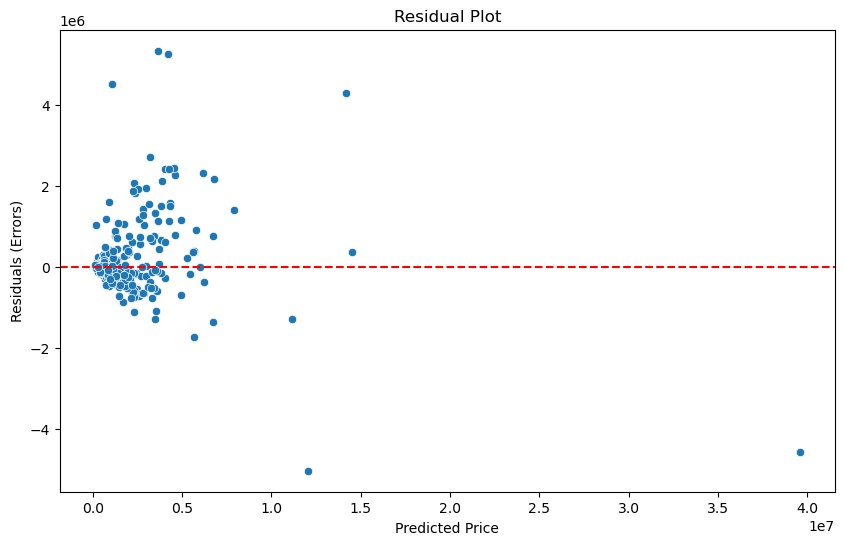

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")

plt.show()

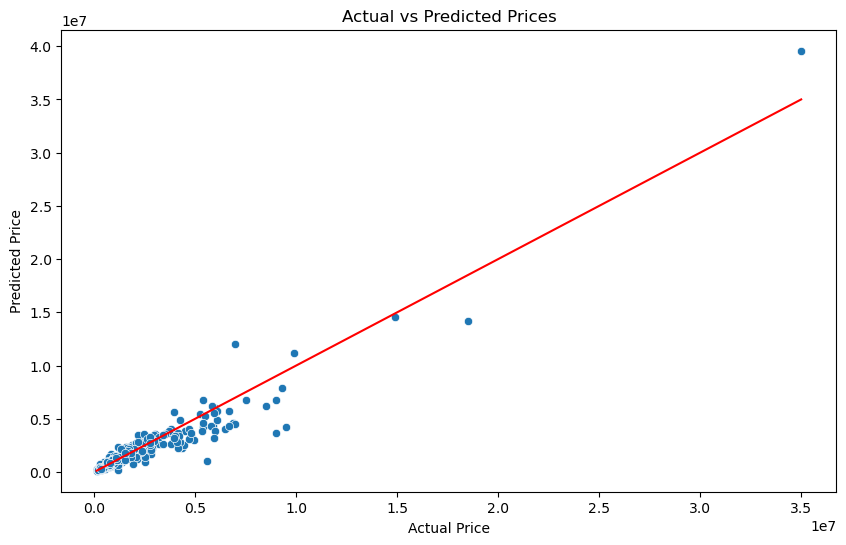

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=y_test_actual, y=y_pred)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [46]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
12,Fuel Type_Hybrid,0.780312,0.780312
22,Owner_UnRegistered Car,0.778366,0.778366
112,Location_Unnao,-0.750981,0.750981
108,Location_Siliguri,-0.729665,0.729665
37,Color_Pink,0.515777,0.515777
38,Color_Purple,0.439620,0.439620
18,Owner_First,0.434946,0.434946
114,Location_Valsad,-0.433885,0.433885
20,Owner_Second,0.419889,0.419889
59,Location_Dharwad,0.379395,0.379395


In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y_log,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores)
print("Average R2:", cv_scores.mean())

Cross Validation Scores: [0.91338032 0.90532925 0.85126621 0.91935579 0.91890763]
Average R2: 0.9016478409644277


In [48]:
import pickle

model_data = {
    "model": model,
    "features": X.columns.tolist()
}

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [65]:
from sklearn.ensemble import RandomForestRegressor

In [66]:
X_rf = X.copy()

In [67]:
X_rf = X_rf.astype(int)

In [73]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
rf_model.fit(X_train_rf, y_train_rf)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
y_pred_rf = rf_model.predict(X_test_rf)

In [76]:
print("Random Forest MAE:", mean_absolute_error(y_test_rf, y_pred_rf))
print("Random Forest R2:", r2_score(y_test_rf, y_pred_rf))

Random Forest MAE: 303426.8945889968
Random Forest R2: 0.8149097402697199


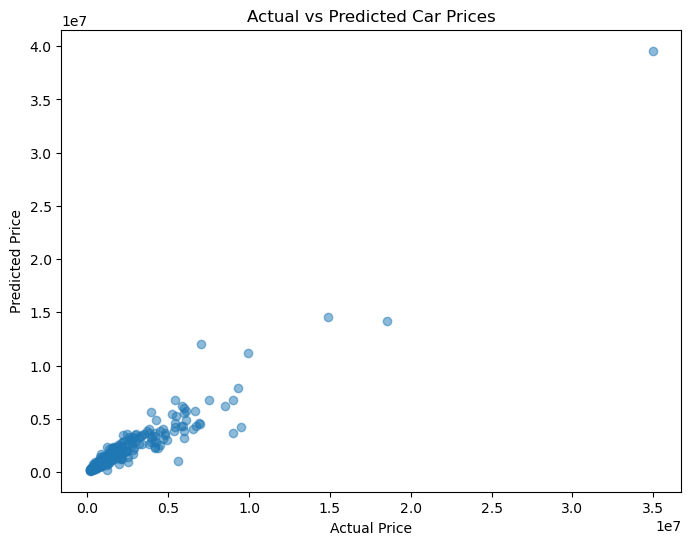

In [85]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_actual, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

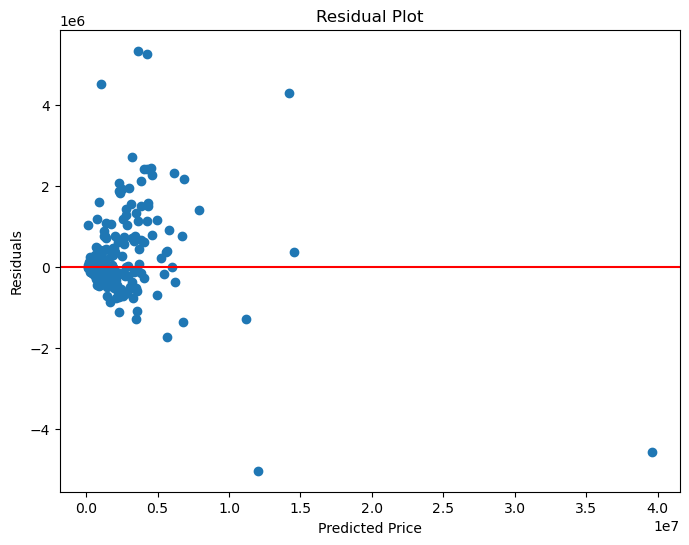

In [86]:
residuals = y_test_actual - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [87]:
import pickle

model_data = {
    "model": model,
    "features": X.columns.tolist()
}

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(model_data, f)